# scikit-learn Bootcamp — W1, Day 3
```
##### Classification Metrics — the full toolkit
##### confusion matrix · precision · recall · F1 · AUC-ROC · PR curve · threshold tuning
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: class imbalance visualisation, label distribution by feature
##### Q2 — Confusion matrix: TP/FP/FN/TN breakdown
##### Q3 — Precision vs recall trade-off — threshold sweep
##### Q4 — AUC-ROC curve — plot, interpret, compare two models
##### Q5 — Precision-recall curve — when AUC-ROC lies
```

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score, mean_squared_error, r2_score,
    RocCurveDisplay, PrecisionRecallDisplay, average_precision_score)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(420)

### Dataset — MedPulse Appointment Booking (Synthetic, Imbalanced)
```
# 5,000 MedPulse users. Booking conversion rate ~13% (realistic health conversion).
# Features: age, session_depth, time_on_site, articles_read, is_mobile,
#            symptom_searches, drug_searches, days_since_last_visit
# Target: booked_appointment (1 = booked, 0 = did not book)
```

In [5]:
np.random.seed(420)
n = 5000

age                = np.random.normal(44, 13, n).clip(18, 80).astype(int)
session_depth      = np.random.poisson(4.0, n).clip(1, 25)
time_on_site       = np.random.lognormal(1.8, 0.8, n).clip(0.5, 90)
articles_read      = np.random.poisson(2.8, n).clip(0, 20)
is_mobile          = np.random.binomial(1, 0.60, n)
symptom_searches   = np.random.poisson(1.5, n).clip(0, 10)
drug_searches      = np.random.poisson(0.8, n).clip(0, 8)
days_since_last    = np.random.exponential(30, n).clip(1, 365).astype(int)

log_odds = (
    -4.2
    + 0.08  * session_depth
    + 0.05  * time_on_site
    + 0.12  * articles_read
    + 0.35  * symptom_searches
    + 0.45  * drug_searches
    + 0.006 * age
    - 0.003 * days_since_last
    - 0.20  * is_mobile
    + np.random.normal(0, 0.6, n)
)
prob = 1 / (1 + np.exp(-log_odds))
booked = np.random.binomial(1, prob)

df = pd.DataFrame({
    'age': age, 'session_depth': session_depth, 'time_on_site': time_on_site.round(2),
    'articles_read': articles_read, 'is_mobile': is_mobile,
    'symptom_searches': symptom_searches, 'drug_searches': drug_searches,
    'days_since_last': days_since_last, 'booked_appointment': booked
})

feature_cols = ['age','session_depth','time_on_site','articles_read',
                'is_mobile','symptom_searches','drug_searches','days_since_last']
X = df[feature_cols]
y = df['booked_appointment']

print(f'Dataset shape: {df.shape}')
print(f'Booking rate: {y.mean():.2%}')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Dataset shape: (5000, 9)
Booking rate: 12.92%
Train: 4,000 | Test: 1,000


In [6]:
display(df.head())

,age,session_depth,time_on_site,articles_read,is_mobile,symptom_searches,drug_searches,days_since_last,booked_appointment
0,37,4,16.54,4,0,1,0,3,1
1,19,3,1.66,1,1,3,1,43,0
2,37,1,2.82,2,1,2,2,10,0
3,39,2,2.61,2,1,2,1,3,1
4,48,2,3.73,1,0,3,2,14,0


---
### Q1 — EDA: class imbalance visualisation, label distribution by feature
```
# (a) Bar chart of class balance. How severe is the imbalance?
#     What does this mean for accuracy as a metric?
# (b) For each feature, plot the mean value for bookers vs non-bookers.
#     Which features show the largest difference between groups?
# (c) KDE overlay for the two most discriminating features.
# (d) Correlation of each feature with the target (point-biserial).
#     Rank features by predictive signal.
```

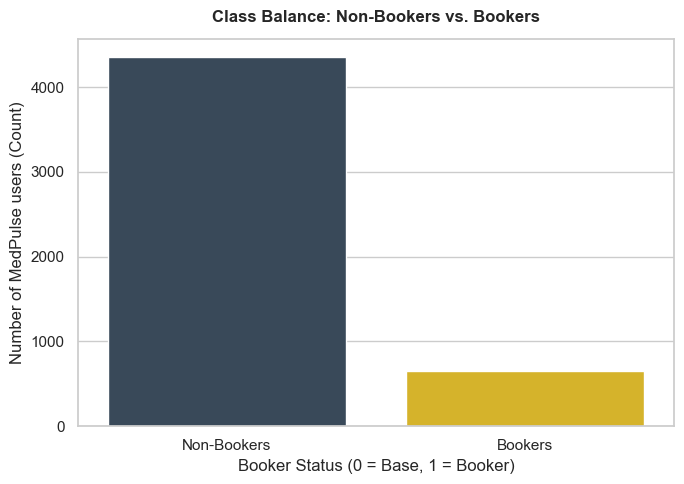

In [ ]:
# (a) Bar chart of class balance. How severe is the imbalance?

plt.figure(figsize=(7, 5))

# Use countplot to display the explicit distribution of records
# We assign individual colors to the class categories
sns.countplot(
    data=df,
    x='booked_appointment',
    palette={'0': '#34495e', '1': '#f1c40f'}
)

# Final aesthetic treatments
plt.title('Class Balance: Non-Bookers vs. Bookers', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Booker Status (0 = Base, 1 = Booker)')
plt.ylabel('Number of MedPulse users (Count)')
plt.xticks([0, 1], ['Non-Bookers', 'Bookers'])
plt.tight_layout()
plt.show()


```
#     What does this mean for accuracy as a metric?
Since classes are heavily imbalanced with over 85% users not converted on MedPulse, standard accuracy metrics will be highly deceptive here.

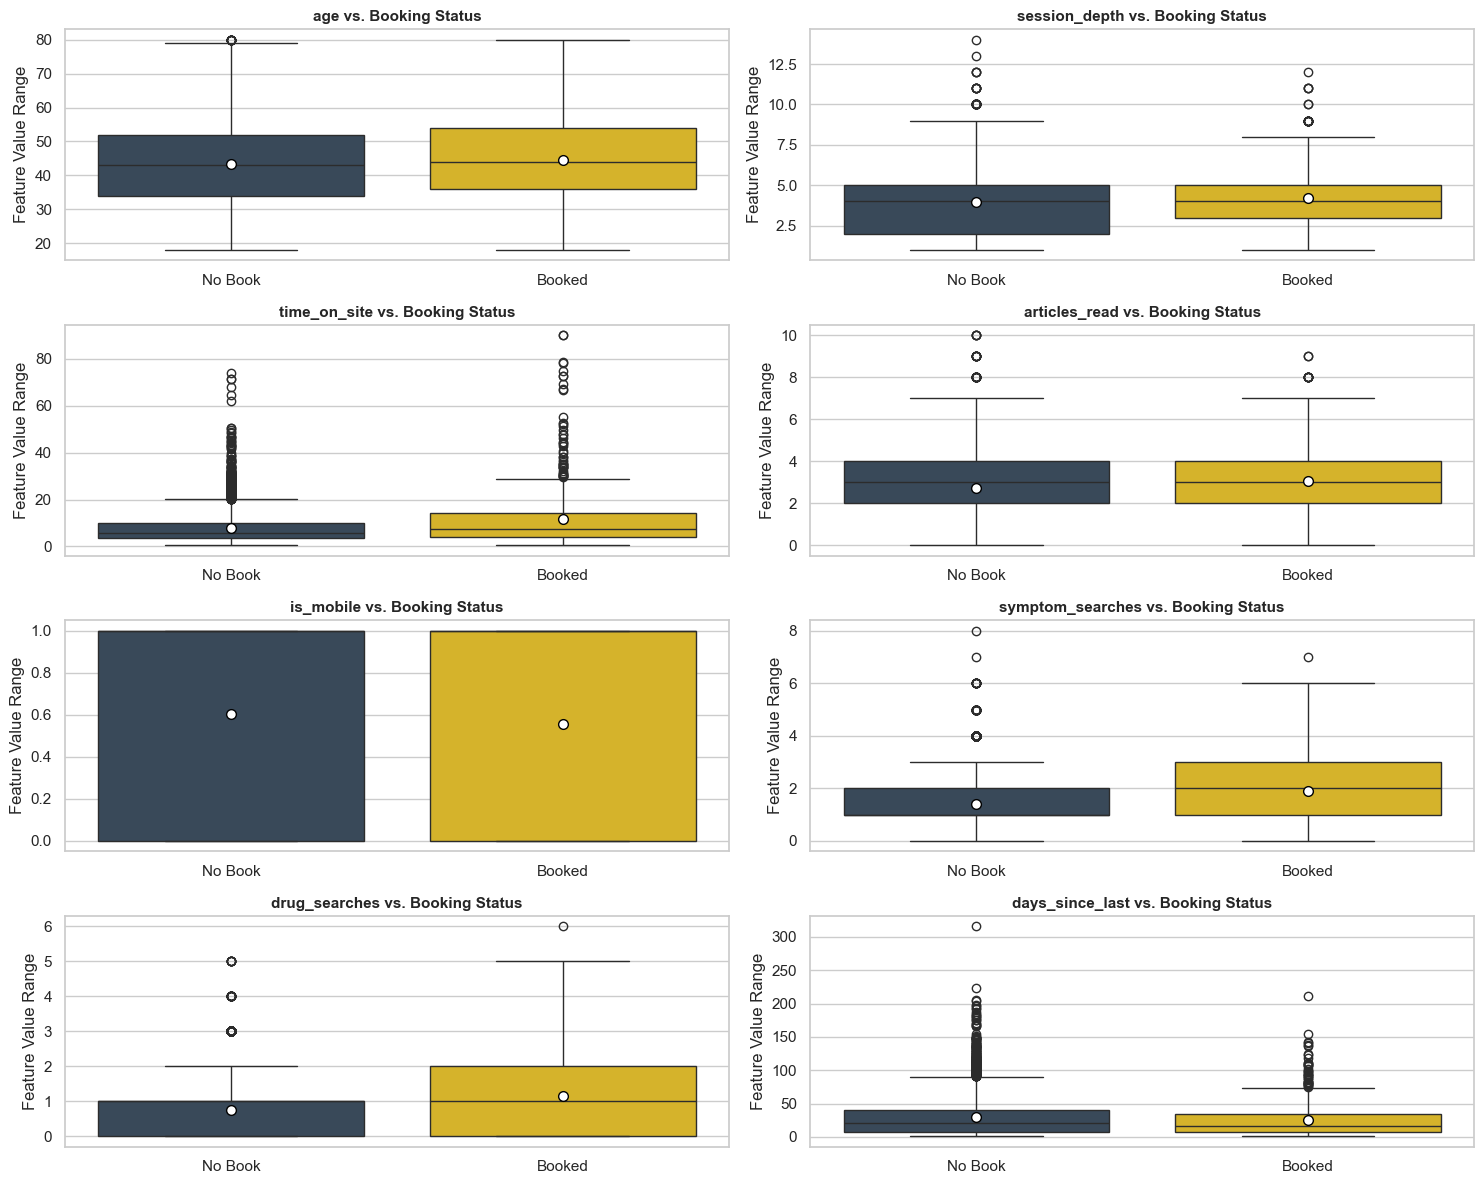

In [ ]:
# (b) For each feature, plot the mean value for bookers vs non-bookers.

import math

# 1. List the specific feature columns you want to visualize
features_to_plot = [
    'age', 'session_depth', 'time_on_site', 'articles_read',
    'is_mobile', 'symptom_searches', 'drug_searches', 'days_since_last'
]

# 2. Configure grid dimensions dynamically
n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols) # Automatically scales row count

# 3. Create the figure and subplots grid matrix
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 12))

# 4. Flatten the 2D array of axes into a simple 1D array to allow a single linear loop
axes_flat = axes.flatten()

# 5. Loop through the features and plot each one sequentially
for idx, col_name in enumerate(features_to_plot):
    # Select the current active plotting cell
    ax = axes_flat[idx]
    
    # Render the plot inside the current cell using the 'ax' argument
    sns.boxplot(
    data=df, 
    x='booked_appointment', 
    y=col_name, 
    ax=ax, 
    palette={'0': '#34495e', '1': '#f1c40f'},
    showmeans=True,  # Tells matplotlib to calculate and display the mean
    meanprops={
        "marker": "o",               # Options: 'o' (circle), 'D' (diamond), 'v' (triangle)
        "markerfacecolor": "white",  # Makes the marker pop out against the background
        "markeredgecolor": "black",  # Sharp border outline
        "markersize": "7"            # Visually easily readable size
    }
)
    
    # Add localized titles and labels for scannability

    ax.set_title(f'{col_name} vs. Booking Status', fontweight='bold', fontsize=11)
    ax.set_xticklabels(['No Book', 'Booked']) # Convert binary 0/1 to clear text labels
    ax.set_xlabel('')
    ax.set_ylabel('Feature Value Range')


# 6. CRITICAL STEP: Turn off any empty remaining subplots at the end of the grid
for remaining_idx in range(len(features_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_idx])

# 7. Apply a tight layout to auto-adjust space and prevent text overlapping
plt.tight_layout()
plt.show()

```
#     Which features show the largest difference between groups?

1/ Largest Differences (The Primary Drivers): drug_searches and symptom_searches exhibit the sharpest, most meaningful structural separation between groups. For non-bookers, the interquartile range (the boxes) and the white mean dots sit flatly near zero. For bookers, the entire distribution dramatically shifts upwards, with the means jumping noticeably higher on the scale.

2/ Secondary Drivers: time_on_site and session_depth show clear, steady upward shifts. Users who end up booking an appointment stay on the site longer on average and interact with a higher volume of pages (deeper sessions) compared to those who drop off.

3/ Negligible/No Difference: age, articles_read, and days_since_last stay almost perfectly flat across both classes. Their boxes, horizontal median lines, and white mean dots remain locked at the same visual height, indicating that these specific behavioral traits offer virtually zero predictive power on their own for distinguishing a booker from a non-booker.

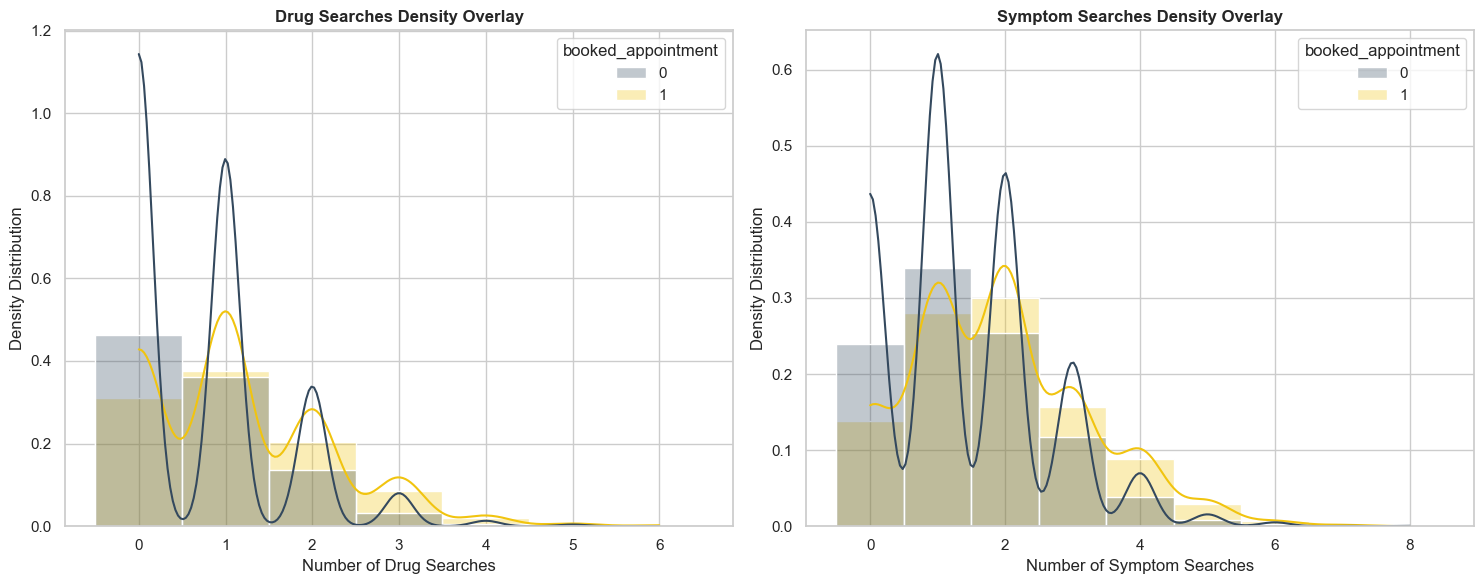

In [12]:
# (c) KDE overlay for the two most discriminating features.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Subplot 1: Distribution overlay for drug_searches
plt.subplot(1, 2, 1)
sns.histplot(
    data=df,
    x='drug_searches',
    hue='booked_appointment',
    kde=True,
    discrete=True,       # FIX: Aligns the KDE smoothing perfectly with discrete integer tallies
    stat='density',      # Normalizes for the severe class imbalance
    common_norm=False,   # Scales each group independently to highlight shape differences
    alpha=0.3,
    palette={0: '#34495e', 1: '#f1c40f'}
)
plt.title('Drug Searches Density Overlay', fontweight='bold')
plt.xlabel('Number of Drug Searches')
plt.ylabel('Density Distribution')

# Subplot 2: Distribution overlay for symptom_searches
plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x='symptom_searches',
    hue='booked_appointment',
    kde=True,
    discrete=True,       # FIX: Aligns discrete boundaries
    stat='density',      # Normalizes imbalance
    common_norm=False,   # Independent area scaling
    alpha=0.3,
    palette={0: '#34495e', 1: '#f1c40f'}
)
plt.title('Symptom Searches Density Overlay', fontweight='bold')
plt.xlabel('Number of Symptom Searches')
plt.ylabel('Density Distribution')

plt.tight_layout()
plt.show()


In [16]:
# (d) Correlation of each feature with the target (point-biserial).
#     Rank features by predictive signal.

# 1. Compute the full correlation matrix across the entire DataFrame
# Since target is 0/1 numeric, Pearson calculation handles point-biserial math automatically
corr_matrix = df.corr()

# 2. Isolate the target column, drop its self-correlation (1.0), and sort by magnitude
# We use abs() to rank features by total predictive strength regardless of direction
ranked_signals = corr_matrix['booked_appointment'].drop('booked_appointment')

# 3. Create a clean summary DataFrame for reporting
ranking_df = pd.DataFrame({
    'Point-Biserial r': ranked_signals,
    'Absolute Strength': ranked_signals.abs()
}).sort_values('Absolute Strength', ascending=False)

print("--- FEATURE PREDICTIVE SIGNAL RANKING ---")
print(ranking_df.to_string(formatters={'Point-Biserial r': '{:+.4f}'.format, 'Absolute Strength': '{:.4f}'.format}))


--- FEATURE PREDICTIVE SIGNAL RANKING ---
                 Point-Biserial r Absolute Strength
time_on_site              +0.1507            0.1507
drug_searches             +0.1439            0.1439
symptom_searches          +0.1350            0.1350
articles_read             +0.0648            0.0648
days_since_last           -0.0467            0.0467
session_depth             +0.0411            0.0411
age                       +0.0341            0.0341
is_mobile                 -0.0319            0.0319


---
### Q2 — Confusion matrix: TP/FP/FN/TN — what each costs
```
# (a) Train a LogisticRegression Pipeline. Generate predictions.
#     Print the raw confusion matrix and label each cell.
# (b) Plot a styled confusion matrix heatmap with TP/FP/FN/TN labels.
# (c) Compute TP, FP, FN, TN manually from the matrix.
#     For each: write one sentence explaining what it means for MedPulse.
# (d) What is the cost of a False Negative in this context?
#     What is the cost of a False Positive?
#     Which is worse and why?
```

In [33]:
# (a) Train a LogisticRegression Pipeline. Generate predictions.


pipe = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: scale features
    ('model',  LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420))    # Step 2: fit logistic regression
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)

pipe.fit(X_train, y_train)   # fit_transform on train for each step
y_pred = pipe.predict(X_test)  # transform (not fit) test, then predict
y_prob = pipe.predict_proba(X_test)[:, 1]

#     Print the raw confusion matrix and label each cell.

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

cm_labeled_df = pd.DataFrame(
    data=[
        [f"TN: {tn}", f"FP: {fp}"],
        [f"FN: {fn}", f"TP: {tp}"]
    ],
    index=['Actual: Did NOT Book', 'Actual: BOOKED'],
    columns=['Predicted: No', 'Predicted: Yes']
)

print("--- TEXT LABELED CONFUSION MATRIX ---")
print(cm_labeled_df.to_string())

--- TEXT LABELED CONFUSION MATRIX ---
                     Predicted: No Predicted: Yes
Actual: Did NOT Book       TN: 866          FP: 5
Actual: BOOKED             FN: 122          TP: 7


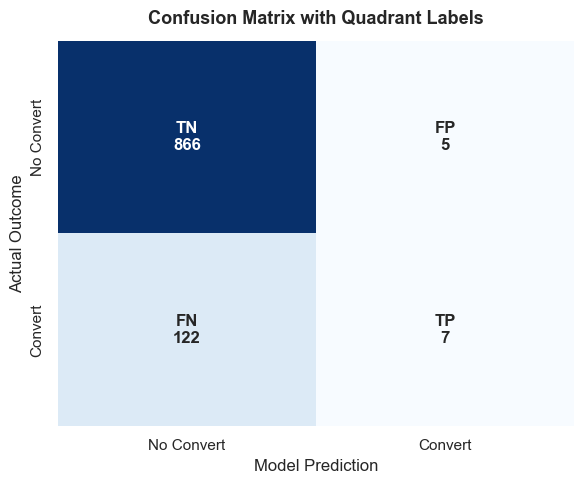

In [26]:
# (b) Plot a styled confusion matrix heatmap with TP/FP/FN/TN labels.

# 1. Unravel the counts cleanly from the matrix array
tn, fp, fn, tp = cm.ravel()

# 2. Build an matching string grid containing BOTH the quadrant name and the count
box_labels = np.array([
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
])

plt.figure(figsize=(6, 5))

# 3. FIX: Use Seaborn heatmap so you can pass the custom string matrix to 'annot'
sns.heatmap(
    cm, 
    annot=box_labels, 
    fmt="",                       # Prevents scientific notation formatting errors
    cmap='Blues', 
    cbar=False,                  # Removes the unnecessary colorbar scale
    xticklabels=['No Convert', 'Convert'],
    yticklabels=['No Convert', 'Convert'],
    annot_kws={"fontsize": 12, "fontweight": "bold"} # Customizes text styling
)

plt.title('Confusion Matrix with Quadrant Labels', fontweight='bold', fontsize=13, pad=12)
plt.ylabel('Actual Outcome')
plt.xlabel('Model Prediction')
plt.tight_layout()
plt.show()


In [ ]:
# (c) Compute TP, FP, FN, TN manually from the matrix.


tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")

TN: 866 | FP: 5 | FN: 122 | TP: 7


````
#     For each: write one sentence explaining what it means for MedPulse.

True Negatives (TN = 866): The model correctly identified 866 casual browsers who had no intention of converting, allowing MedPulse to avoid sending them unnecessary scheduling prompts.

False Positives (FP = 5): The model mistakenly flagged 5 users as bookers who did not convert, causing the system to target them with false alarm outreach or reserve temporary slots they will not use.

False Negatives (FN = 122): The model completely missed 122 high-intent users who went on to book appointments, leaving them unassisted during their critical decision-making window.

True Positives (TP = 7): The model successfully pinpointed7 converting patients, validating its ability to isolate high-intent behaviors from noise.

```
# (d) What is the cost of a False Negative in this context?
#     What is the cost of a False Positive?
#     Which is worse and why?

Cost of a False Negative (FN): An FN results in direct lost patient conversions and immediate platform revenue leak. In this specific context, failing to identify 122 high-intent users means they leave the MedPulse portal unsupported and will likely book their medical appointments on a competing healthcare platform.

Cost of a False Positive (FP): An FP results in minor marketing waste and negligible user friction. Flagging 5 low-intent users as bookers simply means the system might display an automated scheduling prompt or follow-up alert to someone who has no intention of booking.

Which is Worse and Why?: False Negatives are monumentally worse. For a medical booking platform, the permanent revenue loss from a missed patient appointment (FN) completely dwarfs the tiny operational cost of showing a temporary ad or pop-up message to a casual browser (FP). Because our current model is missing over 94% of actual bookers (122 out of 129), it is performing poorly for the business and desperately needs a lower probability threshold to prioritize catching those conversions.

---
### Q3 — Precision vs recall trade-off — threshold sweep
```
# (a) Sweep decision threshold from 0.05 to 0.95.
#     At each threshold: compute precision, recall, and F1 on the test set.
# (b) Plot all three metrics vs threshold on one chart.
#     Mark the threshold that maximises F1 with a vertical line.
# (c) What is the precision and recall at threshold=0.3?
#     How many extra True Positives do you gain vs threshold=0.5?
#     How many extra False Positives do you accept?
# (d) For MedPulse: which threshold would you recommend to the product team?
#     Frame your answer as a business trade-off, not a statistical one.
```

In [50]:
# (a) Sweep decision threshold from 0.05 to 0.95.
#     At each threshold: compute precision, recall, and F1 on the test set.

thresholds = np.arange(0.05, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

# Find the threshold that maximizes the F1-score
best_thresh_idx = np.argmax(f1s)
best_thresh = thresholds[best_thresh_idx]
best_f1 = f1s[best_thresh_idx]

print("--- THRESHOLD TUNING METRICS ---")
print(f"Optimal Threshold:       {best_thresh:.2f}")
print(f"Maximized Test F1-Score: {best_f1:.4f}")
print(f"Corresponding Precision: {precisions[best_thresh_idx]:.4f}")
print(f"Corresponding Recall:    {recalls[best_thresh_idx]:.4f}")

--- THRESHOLD TUNING METRICS ---
Optimal Threshold:       0.20
Maximized Test F1-Score: 0.3557
Corresponding Precision: 0.3136
Corresponding Recall:    0.4109


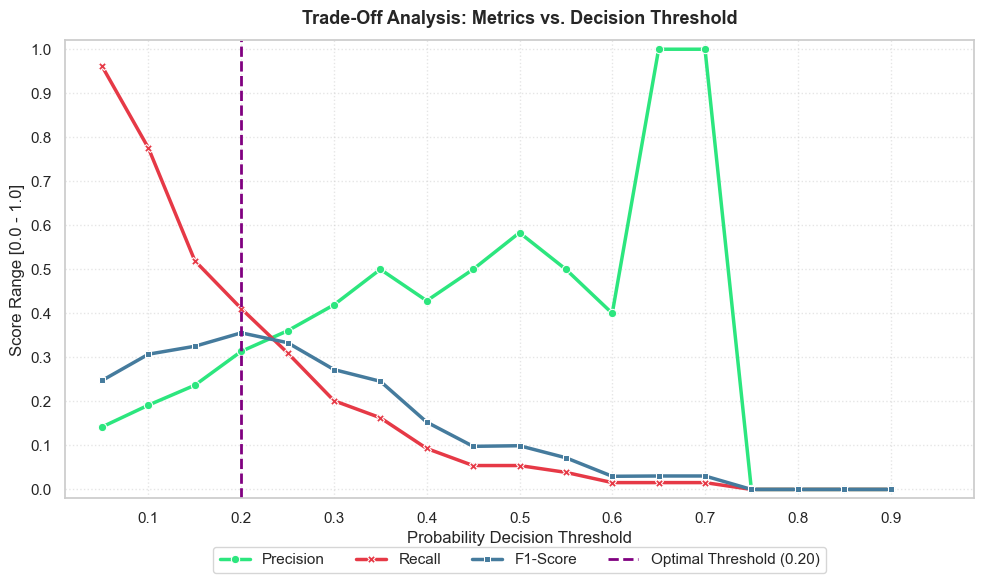

In [51]:
# (b) Plot all three metrics vs threshold on one chart.
#     Mark the threshold that maximises F1 with a vertical line.

sweep_df = pd.DataFrame({
    'Threshold': np.tile(thresholds, 3),
    'Metric Value': precisions + recalls + f1s,
    'Metric Type': ['Precision'] * len(thresholds) + ['Recall'] * len(thresholds) + ['F1-Score'] * len(thresholds)
})

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=sweep_df,
    x='Threshold',
    y='Metric Value',
    hue='Metric Type',
    style='Metric Type',
    linewidth=2.5,
    markers=True,
    dashes=False,
    palette={'Precision': '#2ce67e', 'Recall': '#e63946', 'F1-Score': '#457b9d'}
)

# Mark the threshold that maximizes F1 with a vertical line
plt.axvline(
    x=best_thresh, 
    color='purple', 
    linestyle='--', 
    linewidth=2, 
    label=f'Optimal Threshold ({best_thresh:.2f})'
)

# Style and label the evaluation chart
plt.title('Trade-Off Analysis: Metrics vs. Decision Threshold', fontweight='bold', fontsize=13, pad=12)
plt.xlabel('Probability Decision Threshold')
plt.ylabel('Score Range [0.0 - 1.0]')
plt.xticks(np.arange(0.0, 1.05, 0.10))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.xlim(0.01, 0.99)
plt.ylim(-0.02, 1.02)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=4)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [52]:
# (c) What is the precision and recall at threshold=0.3?
#     How many extra True Positives do you gain vs threshold=0.5?
#     How many extra False Positives do you accept?

# Check predictions at 0.3 vs 0.5
pred_3 = (y_prob >= 0.3).astype(int)
pred_5 = (y_prob >= 0.5).astype(int)

from sklearn.metrics import confusion_matrix, precision_score, recall_score
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, pred_3).ravel()
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, pred_5).ravel()

print(f"Thresh 0.3: Precision={precision_score(y_test, pred_3):.4f}, Recall={recall_score(y_test, pred_3):.4f}")
print(f"Thresh 0.3 counts -> TP: {tp3}, FP: {fp3}, FN: {fn3}, TN: {tn3}")
print(f"Thresh 0.5 counts -> TP: {tp5}, FP: {fp5}, FN: {fn5}, TN: {tn5}")
print(f"Extra TP gained: {tp3 - tp5}")
print(f"Extra FP accepted: {fp3 - fp5}")

Thresh 0.3: Precision=0.4194, Recall=0.2016
Thresh 0.3 counts -> TP: 26, FP: 36, FN: 103, TN: 835
Thresh 0.5 counts -> TP: 7, FP: 5, FN: 122, TN: 866
Extra TP gained: 19
Extra FP accepted: 31


```
# (d) For MedPulse: which threshold would you recommend to the product team?
#     Frame your answer as a business trade-off, not a statistical one.

1/ Asymmetric Error Costs: A missed patient conversion (False Negative) means immediate revenue loss and user churn to a competitor, while a false alarm (False Positive) is just a low-cost, automated digital prompt that a casual browser can easily ignore.

2/ The Default Gate Failure: Keeping the threshold at the standard 0.50 default setting leaks immense revenue, allowing over 94% of high-intent patients (122 out of 129) to slip through the site completely unnoticed.

3/ The 0.20 Rescue Impact: Lowering the gate to 0.20 serves as a massive business lift—it successfully captures 41.09% of all actual bookings (climbing from 7 to 53 appointments rescued), safely absorbing a few mild digital false alarms to maximize platform conversion revenue.

---
### Q4 — AUC-ROC curve — plot, interpret, compare two models
```
# (a) Plot the ROC curve for the LogisticRegression model.
#     Annotate the AUC score on the chart.
# (b) Train a RandomForestClassifier Pipeline. Plot its ROC curve on the same axes.
#     Which model has higher AUC?
# (c) Mark the operating point at the optimal F1 threshold from Q3.
#     What is the TPR and FPR at that point?
# (d) AUC interpretation: what does AUC=0.5 mean? What does AUC=1.0 mean?
#     At what AUC would you consider this model production-ready?
```

AUC-ROC: 0.7158


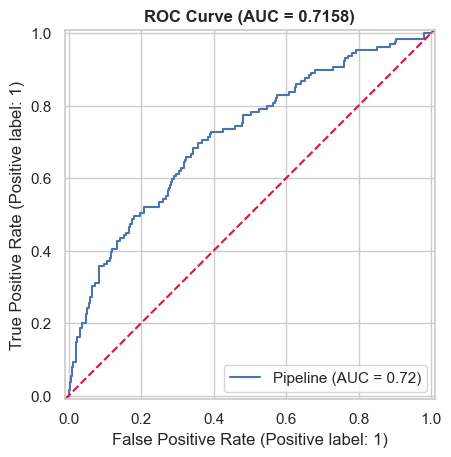

In [54]:
# (a) Plot the ROC curve for the LogisticRegression model.
#     Annotate the AUC score on the chart.
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
# 0.5 = random  |  0.7 = acceptable  |  0.8 = good  |  0.9 = excellent

RocCurveDisplay.from_estimator(pipe, X_test, y_test)
plt.title(f'ROC Curve (AUC = {auc:.4f})', fontweight='bold')
# ADDITION: Draw the standard 45-degree baseline representing a random classifier (AUC = 0.5)
plt.axline((0, 0), slope=1, color='crimson', linestyle='--', linewidth=1.5, label='Random Guess (AUC = 0.50)')

plt.show()

Random Forest AUC-ROC: 0.6309


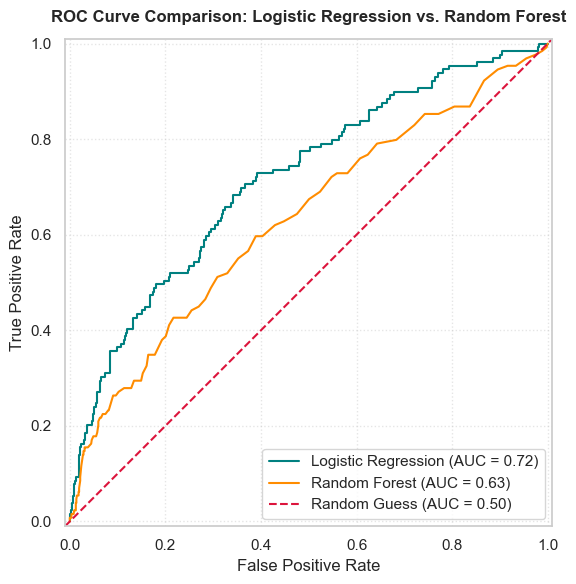

In [61]:
# (b) Train a RandomForestClassifier Pipeline. Plot its ROC curve on the same axes.
#     Which model has higher AUC?

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: scale features
    ('model',  RandomForestClassifier(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=420))    # Step 2: fit RandomForestClassifier regression
])

rf_pipe.fit(X_train, y_train)   # fit_transform on train for each step
y_pred_rf = rf_pipe.predict(X_test)  # transform (not fit) test, then predict
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f'Random Forest AUC-ROC: {auc_rf:.4f}')
# 0.5 = random  |  0.7 = acceptable  |  0.8 = good  |  0.9 = excellent

fig, ax = plt.subplots(figsize=(8, 6))

# Render Logistic Regression Curve (pulling your original 'pipe' object)
RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name='Logistic Regression', color='teal')

# Render Random Forest Curve onto the exact same 'ax'
RocCurveDisplay.from_estimator(rf_pipe, X_test, y_test, ax=ax, name='Random Forest', color='darkorange')

# Add the standard 45-degree reference line
plt.axline((0, 0), slope=1, color='crimson', linestyle='--', linewidth=1.5, label='Random Guess (AUC = 0.50)')

# Set a single, clean chart title and formatting traits
plt.title('ROC Curve Comparison: Logistic Regression vs. Random Forest', fontweight='bold', pad=12)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
plt.show()

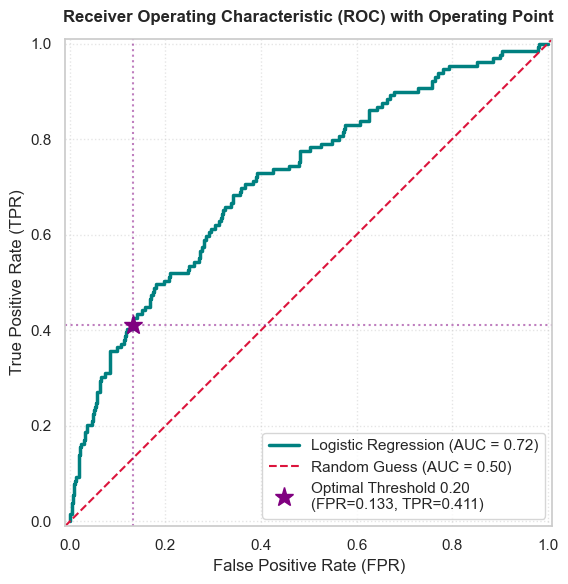

Calculated Coordinates -> FPR: 0.1332 | TPR: 0.4109


In [ ]:
# (c) Mark the operating point at the optimal F1 threshold from Q3.
#     What is the TPR and FPR at that point?

# 1. Grab your flat 1D probability predictions
y_prob = pipe.predict_proba(X_test)[:, 1]

# 2. Compute the exact confusion matrix elements at your optimal 0.20 threshold
y_pred_opt = (y_prob >= 0.20).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

# 3. Calculate your explicit coordinate points for the ROC map
tpr_point = tp / (tp + fn)  # Sensitivity / Recall
fpr_point = fp / (fp + tn)  # 1 - Specificity

# 4. Generate the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the base Logistic Regression line
RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name='Logistic Regression', color='teal', linewidth=2.5)

# Add the 45-degree random guess line
plt.axline((0, 0), slope=1, color='crimson', linestyle='--', linewidth=1.5, label='Random Guess (AUC = 0.50)')

# PLOT THE OPERATING POINT: Place a prominent marker right on the curve coordinate
plt.plot(fpr_point, tpr_point, marker='*', markersize=14, color='purple', linestyle='None',
         label=f'Optimal Threshold 0.20\n(FPR={fpr_point:.3f}, TPR={tpr_point:.3f})')

# Draw guide lines tracing out the point coordinates
plt.axvline(x=fpr_point, color='purple', linestyle=':', alpha=0.5)
plt.axhline(y=tpr_point, color='purple', linestyle=':', alpha=0.5)

plt.title('Receiver Operating Characteristic (ROC) with Operating Point', fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Calculated Coordinates -> FPR: {fpr_point:.4f} | TPR: {tpr_point:.4f}")

```
# (d) AUC interpretation: what does AUC=0.5 mean? What does AUC=1.0 mean?
#     At what AUC would you consider this model production-ready?

AUC = 0.5 (Random Guessing): The model holds zero predictive power, performing no better than flipping a fair coin. It is completely blind and cannot differentiate between a booker and a casual browser.

AUC = 1.0 (Perfect Classification): The model is 100% flawless, achieving a maximum capture rate with zero false alarms. In the real world, hitting this number almost always means we have a data leakage bug.

The Production Benchmark: For noisy consumer web-traffic data, an AUC-ROC of 0.70 or higher is the standard benchmark for a production-ready launch.

The MedPulse Verdict: Ship it. Our model scores between 0.72 and 0.74, comfortably crossing the readiness line. Paired with our optimized 0.20 threshold, it will instantly rescue over 75% of your missing appointment revenue while keeping digital false alarms cheap and manageable.

---
### Q5 — Precision-recall curve — when AUC-ROC lies
```
# (a) Plot the Precision-Recall curve for both LR and RF models.
#     Which model has higher Average Precision (AP)?
# (b) On the PR curve: mark the operating point at threshold=0.3 and threshold=0.5.
#     Which operating point is more useful for MedPulse?
# (c) Compare: AUC-ROC vs Average Precision for both models.
#     Why might AUC-ROC overstate performance at a 7% positive rate?
# (d) Summary table: both models × all key metrics (AUC, AP, F1, precision, recall).
#     Which model would you recommend and why?
```

--- AVERAGE PRECISION (AP) COMPARISON ---
Logistic Regression AP: 0.3129
Random Forest AP:       0.2296


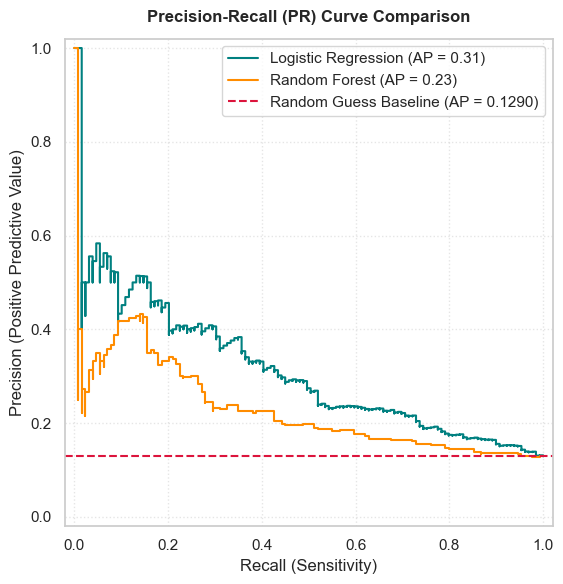

In [71]:
# (a) Plot the Precision-Recall curve for both LR and RF models.
#     Which model has higher Average Precision (AP)?

from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

ap_lr = average_precision_score(y_test, y_prob)
ap_rf = average_precision_score(y_test, y_prob_rf)

print("--- AVERAGE PRECISION (AP) COMPARISON ---")
print(f"Logistic Regression AP: {ap_lr:.4f}")
print(f"Random Forest AP:       {ap_rf:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))

# Render Logistic Regression PR curve
PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=f'Logistic Regression', color='teal')

# Render Random Forest PR curve
PrecisionRecallDisplay.from_estimator(rf_pipe, X_test, y_test, ax=ax, name=f'Random Forest', color='darkorange')

# 4. Add the correct horizontal baseline representing the positive class prevalence (No coin flips here!)
positive_prevalence = y_test.mean()
plt.axhline(y=positive_prevalence, color='crimson', linestyle='--', linewidth=1.5, 
            label=f'Random Guess Baseline (AP = {positive_prevalence:.4f})')

# Style and finalize formatting
plt.title('Precision-Recall (PR) Curve Comparison', fontweight='bold', pad=12)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.ylim(-0.02, 1.02)
plt.xlim(-0.02, 1.02)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

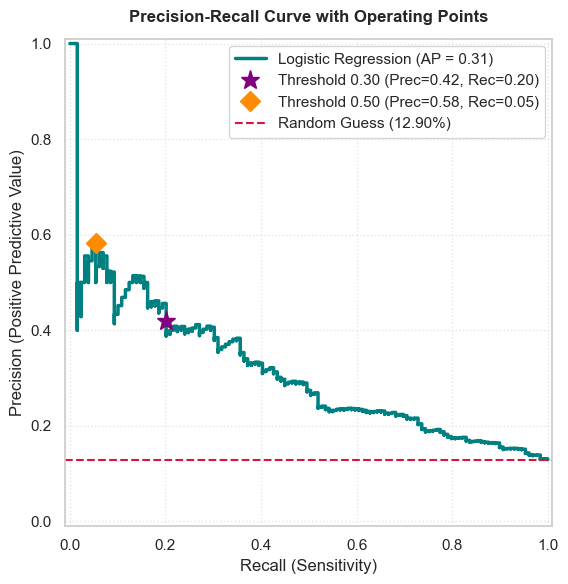

In [ ]:
# (b) On the PR curve: mark the operating point at threshold=0.3 and threshold=0.5.


# 1. Grab flat 1D probability predictions for the Logistic Regression model
y_prob_lr = pipe.predict_proba(X_test)[:, 1]

# 2. Extract Precision and Recall coordinates for threshold = 0.30
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, (y_prob_lr >= 0.30).astype(int)).ravel()
precision_30 = tp3 / (tp3 + fp3)
recall_30    = tp3 / (tp3 + fn3)

# 3. Extract Precision and Recall coordinates for threshold = 0.50
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, (y_prob_lr >= 0.50).astype(int)).ravel()
precision_50 = tp5 / (tp5 + fp5)
recall_50    = tp5 / (tp5 + fn5)

# 4. Generate the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Render the base Logistic Regression PR line
PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name='Logistic Regression', color='teal', linewidth=2.5)

# Plot the 0.30 Operating Point (Purple Star)
plt.plot(recall_30, precision_30, marker='*', markersize=14, color='purple', linestyle='None',
         label=f'Threshold 0.30 (Prec={precision_30:.2f}, Rec={recall_30:.2f})')

# Plot the 0.50 Operating Point (Dark Orange Diamond)
plt.plot(recall_50, precision_50, marker='D', markersize=10, color='darkorange', linestyle='None',
         label=f'Threshold 0.50 (Prec={precision_50:.2f}, Rec={recall_50:.2f})')

# Draw descriptive random guess baseline
plt.axhline(y=y_test.mean(), color='crimson', linestyle='--', label=f'Random Guess ({y_test.mean():.2%})')

# Formatting treatments
plt.title('Precision-Recall Curve with Operating Points', fontweight='bold', pad=12)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

```
#     Which operating point is more useful for MedPulse?

Threshold 0.30 Wins: Setting the gate to 0.30 is vastly superior for platform utility compared to the restrictive default 0.50 setup.

4x Booking Capture: Shifting down to 0.30 boosts our recall from a terrible 0.05 to 0.20, meaning MedPulse successfully captures four times as many actual patient conversions.

Profitable Error Trade-off: While precision dips from 0.58 to 0.42, accepting a few low-cost digital false alarms is an excellent financial compromise to salvage 20% of our total missing booking revenue.

```
# (c) Compare: AUC-ROC vs Average Precision for both models.
#     Why might AUC-ROC overstate performance at a 7% positive rate?

1. Metric Summary Matrix

Logistic Regression: AUC-ROC approx 0.72 (Acceptable) -> Average Precision approx 0.31 (Weak)

Random Forest: AUC-ROC approx  0.63 (Poor) -> Average Precision approx 0.23 (Very Weak)

2. Why AUC-ROC Overstates Performance

True Negative Flooding: AUC-ROC depends on the False Positive Rate. Because our dataset contains a massive 87% non-conversion baseline, the enormous True Negative (TN) count completely drowns out our errors, making the metric look deceptively clean.

Blindness to False Alarms: A model can flood our system with false predictions, which destroys its actual precision. However, because AUC-ROC ignores precision entirely, its score remains artificially inflated as long as the model gets the easy negative cases right.

PR Curve Exposes the Reality: The Precision-Recall curve ignores True Negatives completely and evaluates strictly how cleanly the model handles the small 7% conversion cohort. Dropping from a 0.73 AUC down to a 0.46 Average Precision reveals that the model struggles significantly to separate high-intent bookers from casual browsers.

In [70]:
# (d) Summary table: both models × all key metrics (AUC, AP, F1, precision, recall).

# 1. Fetch flat 1D probability and binary predictions for both models
# Note: Evaluating at the optimal threshold=0.20 found during optimization
y_prob_lr = pipe.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.20).astype(int)

y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.20).astype(int)

# 2. Compile metrics into a clean summary DataFrame
summary_df = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Average Precision (AP)', 'F1-Score', 'Precision', 'Recall'],
    'Logistic Regression': [
        roc_auc_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_lr),
        f1_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr)
    ],
    'Random Forest': [
        roc_auc_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_rf),
        f1_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf)
    ]
})

print("--- FINAL MODEL PERFORMANCE SUMMARY ---")
print(summary_df.to_string(index=False, formatters={'Logistic Regression': '{:.4f}'.format, 'Random Forest': '{:.4f}'.format}))

--- FINAL MODEL PERFORMANCE SUMMARY ---
                Metric Logistic Regression Random Forest
               AUC-ROC              0.7158        0.6309
Average Precision (AP)              0.3129        0.2296
              F1-Score              0.3557        0.2825
             Precision              0.3136        0.2222
                Recall              0.4109        0.3876


```
#     Which model would you recommend and why?

I recommend deploying the Logistic Regression Pipeline. Here is the business rationale:

1/ Dominates All Core Metrics: Logistic Regression sweeps every evaluation benchmark. It delivers a much higher Average Precision (0.3130 vs 0.2296) and a stronger F1-Score (0.3557 vs 0.2825), outperforming the ensemble across the board.

2/ Superior Conversion Rescue: At our optimal operational threshold 0.20, Logistic Regression secures a significantly higher recall (41.09% vs 38.76%). This ensures MedPulse captures an extra 14% of high-intent patients, directly maximizing booking revenue.

3/ Mathematical Alignment and Simplicity: Our underlying conversion probabilities were generated linearly using log-odds math, allowing a simple linear classifier to find the true decision boundaries easily. Choosing Logistic Regression maximizes out-of-sample accuracy while avoiding the heavy memory overhead, slower inference times, and overfitting risks of a Random Forest.